# 01 · 解码数据探索 / Decode & Data Exploration

目标:看清 4 段录音的**点击瞬态形状、SNR、干扰、文件差异**,为后续检测函数设计
(高通截止频率、spectral flux / HFC 参数、峰值拾取阈值)提供数据依据。

输入:`data/wav/*.wav`(48 kHz mono float32,由 `src/decode.py` 生成)。

> 注:本 notebook 中的点击检测只是**探索用的粗检**(高通 + 包络 + find_peaks),
> 不是最终检测器;它仅用于定位若干点击以测量瞬态/频段。

In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf
import scipy.signal as sps
from scipy.ndimage import uniform_filter1d
import librosa, librosa.display
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
WAV_DIR = REPO / 'data' / 'wav'
FIG_DIR = REPO / 'figures'; FIG_DIR.mkdir(exist_ok=True)
SR = 48000
wavs = sorted(WAV_DIR.glob('*.wav'))
print('files:', [w.name for w in wavs])

files: ['BJ_C1.wav', 'BJ_C3.wav', 'F67.wav', 'IntlSB20.wav']


## 分析函数 / Analysis helpers

In [2]:
def load(path):
    y, sr = sf.read(path, dtype='float32')
    if y.ndim > 1:
        y = y.mean(axis=1)
    return y, sr

def highpass(y, sr, fc=2000.0, order=4):
    sos = sps.butter(order, fc / (sr / 2), btype='high', output='sos')
    return sps.sosfiltfilt(sos, y).astype(np.float32)

def global_stats(y, sr):
    """Noise floor (10th pct of frame RMS), peak level, peak-SNR — all in dBFS/dB."""
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    db = 20 * np.log10(rms + 1e-9)
    noise_db = float(np.percentile(db, 10))
    peak_db = float(20 * np.log10(np.max(np.abs(y)) + 1e-9))
    return noise_db, peak_db, peak_db - noise_db

def detect_clicks(y, sr, smooth_ms=1.0, rel_thr=0.12, min_gap_ms=50):
    """Coarse click locator: highpass -> rectified+smoothed envelope -> peak pick."""
    yhp = highpass(y, sr)
    env = uniform_filter1d(np.abs(yhp), size=max(1, int(sr * smooth_ms / 1000)))
    thr = rel_thr * float(env.max())
    peaks, _ = sps.find_peaks(env, height=thr, distance=int(sr * min_gap_ms / 1000))
    return peaks, env, yhp

def transient_and_band(y, env, peaks, sr, win_ms=30, n=40):
    """Median transient duration (-20/-40 dB) and dominant frequency over up to n clicks."""
    durs20, durs40, fpks, cents = [], [], [], []
    half = int(sr * win_ms / 1000)
    nfft = 1024
    for p in peaks[:n]:
        a, b = max(0, p - half), min(len(env), p + half)
        seg = env[a:b]; pk = seg.max()
        m20 = np.where(seg > pk * 0.1)[0]    # within -20 dB of local peak
        m40 = np.where(seg > pk * 0.01)[0]   # within -40 dB
        if len(m20): durs20.append((m20[-1] - m20[0]) / sr * 1000)
        if len(m40): durs40.append((m40[-1] - m40[0]) / sr * 1000)
        wa, wb = max(0, p - int(sr * 0.004)), min(len(y), p + int(sr * 0.004))
        w = y[wa:wb] * np.hanning(wb - wa)
        if len(w) < 8: continue
        S = np.abs(np.fft.rfft(w, nfft)); f = np.fft.rfftfreq(nfft, 1 / sr)
        fpks.append(float(f[np.argmax(S)]))
        cents.append(float((f * S).sum() / (S.sum() + 1e-12)))
    agg = lambda x: (float(np.median(x)) if len(x) else float('nan'))
    return dict(dur20_ms=agg(durs20), dur40_ms=agg(durs40),
                peak_freq=agg(fpks), centroid=agg(cents))

## 统计汇总表 / Per-file summary

In [3]:
results = {}
for w in wavs:
    y, sr = load(w)
    noise_db, peak_db, snr = global_stats(y, sr)
    peaks, env, _ = detect_clicks(y, sr)
    tb = transient_and_band(y, env, peaks, sr)
    results[w.stem] = dict(dur_s=len(y) / sr, n_clicks=int(len(peaks)),
                           noise_db=noise_db, peak_db=peak_db, snr_db=snr, **tb)

hdr = f"{'file':12s}{'dur_s':>8s}{'clicks':>8s}{'noise':>9s}{'peak':>8s}{'SNR':>7s}{'d-20ms':>9s}{'d-40ms':>9s}{'fpk_Hz':>9s}{'cent_Hz':>9s}"
print(hdr); print('-' * len(hdr))
for k, r in results.items():
    print(f"{k:12s}{r['dur_s']:8.1f}{r['n_clicks']:8d}{r['noise_db']:9.1f}{r['peak_db']:8.1f}"
          f"{r['snr_db']:7.1f}{r['dur20_ms']:9.1f}{r['dur40_ms']:9.1f}{r['peak_freq']:9.0f}{r['centroid']:9.0f}")

file           dur_s  clicks    noise    peak    SNR   d-20ms   d-40ms   fpk_Hz  cent_Hz
----------------------------------------------------------------------------------------
BJ_C1          392.7     244    -45.1    -4.5   40.6     56.5     60.0     3469     4350
BJ_C3          278.1     526    -61.0     0.5   61.5     56.9     60.0      352     2972
F67            355.3     651    -51.7    -0.4   51.3     58.2     60.0      469     1327
IntlSB20       366.1    1084    -39.9    -0.2   39.7     58.9     60.0      281     1271


## 整段波形 + 频谱图 / Full waveform + spectrogram

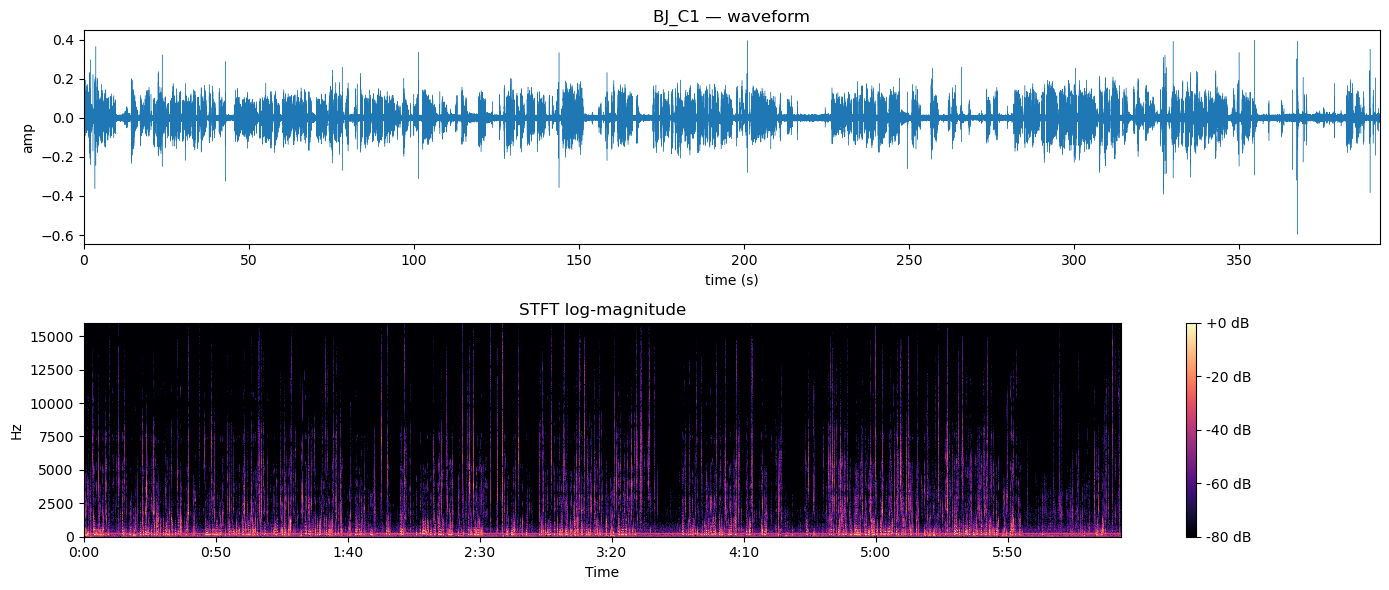

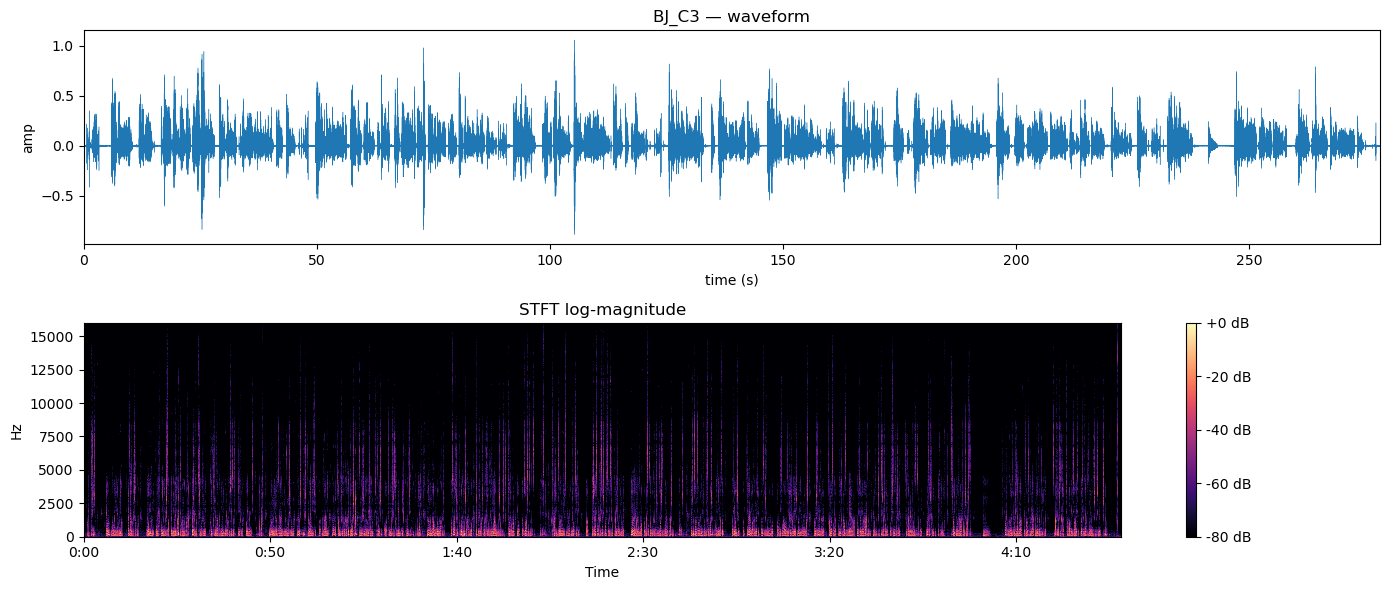

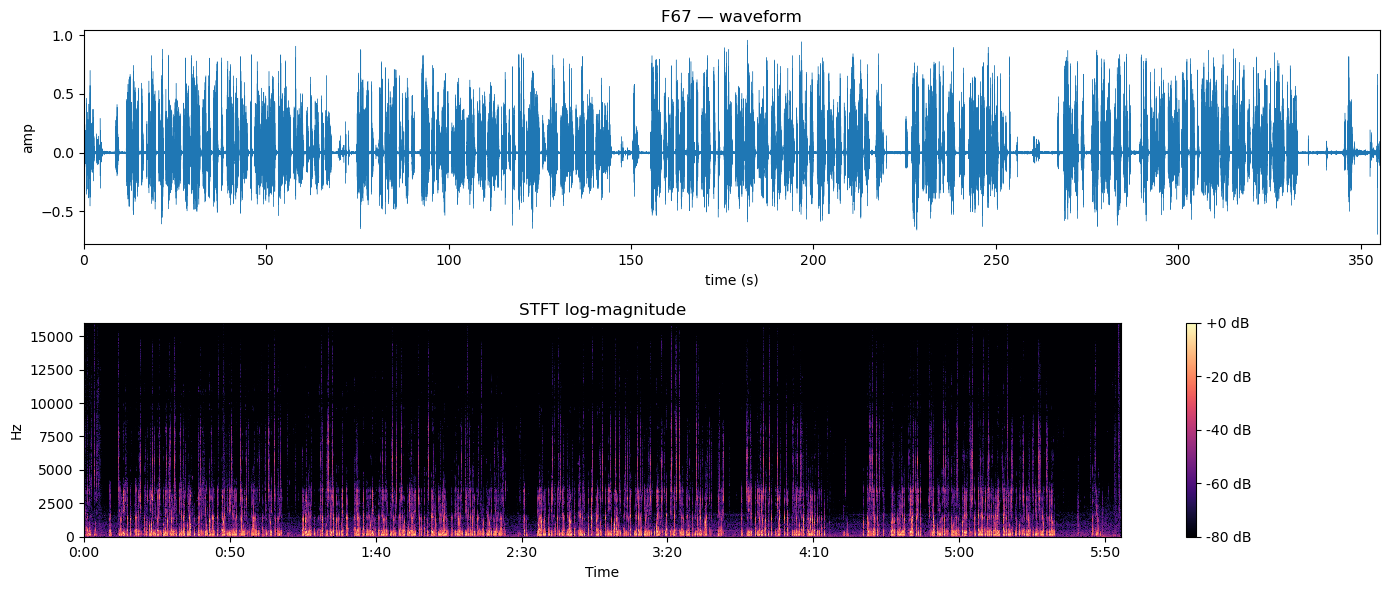

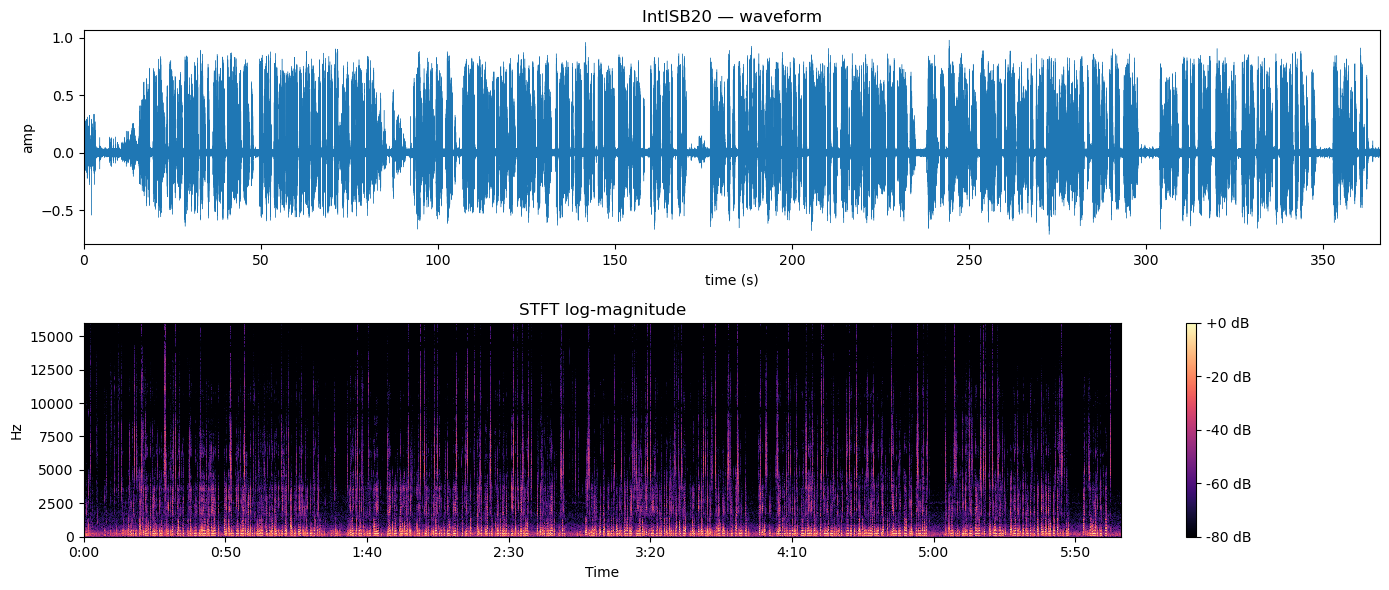

In [4]:
for w in wavs:
    y, sr = load(w)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=2048, hop_length=512)), ref=np.max)
    fig, ax = plt.subplots(2, 1, figsize=(14, 6))
    t = np.arange(len(y)) / sr
    ax[0].plot(t, y, lw=0.3); ax[0].set(title=f'{w.stem} — waveform', xlabel='time (s)', ylabel='amp')
    ax[0].margins(x=0)
    img = librosa.display.specshow(D, sr=sr, hop_length=512, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set(title='STFT log-magnitude', ylim=(0, 16000))
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    fig.tight_layout(); fig.savefig(FIG_DIR / f'{w.stem}_overview.png', dpi=90); plt.show()

## 放大单个点击 / Zoomed individual clicks (±25 ms) + spectra

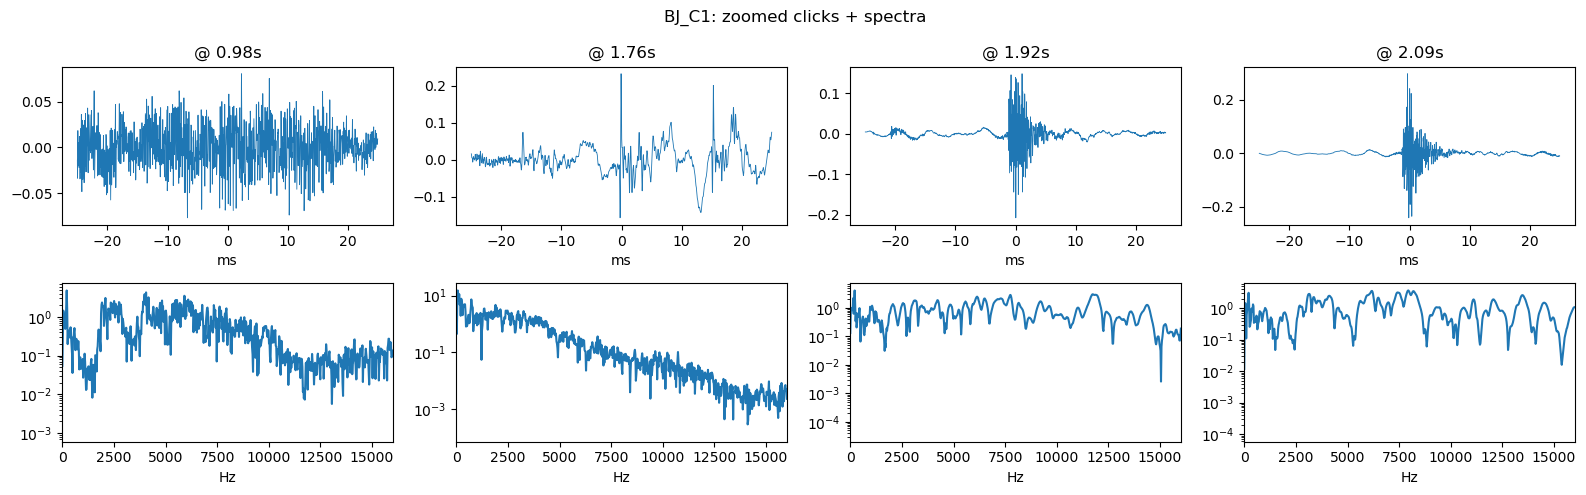

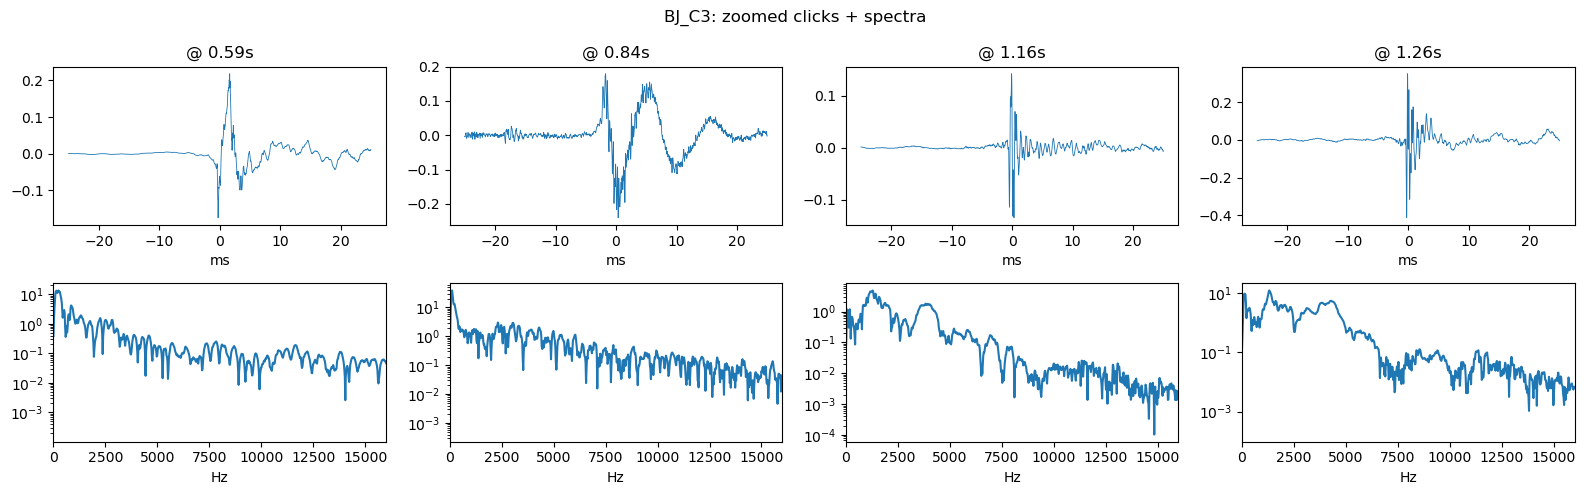

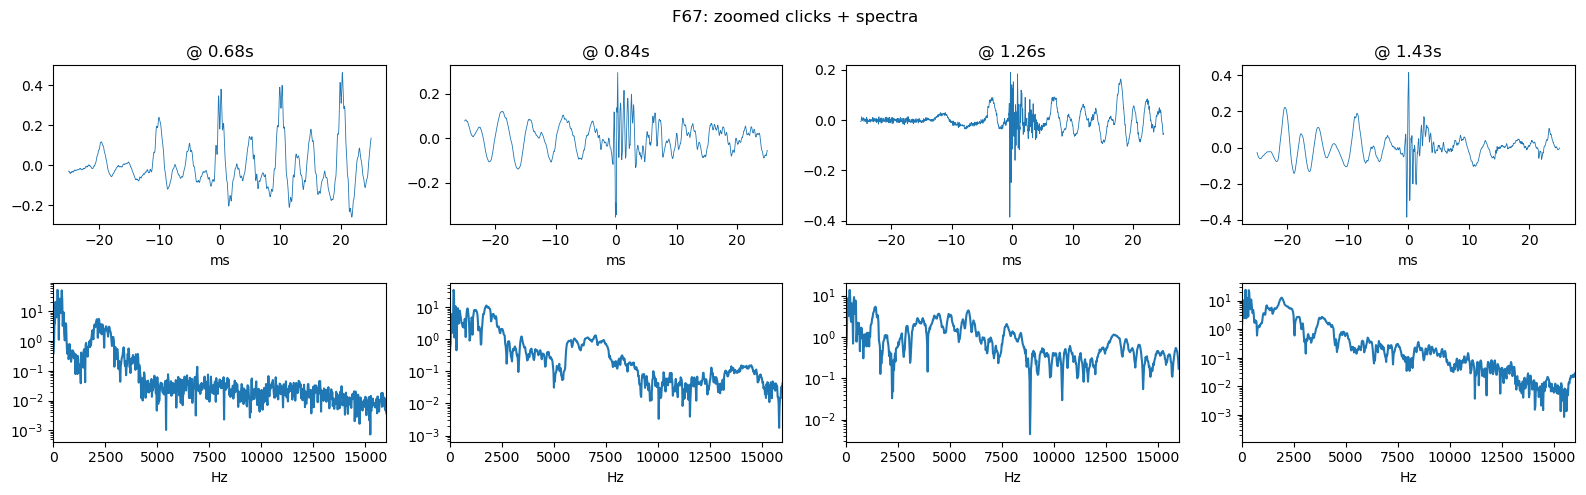

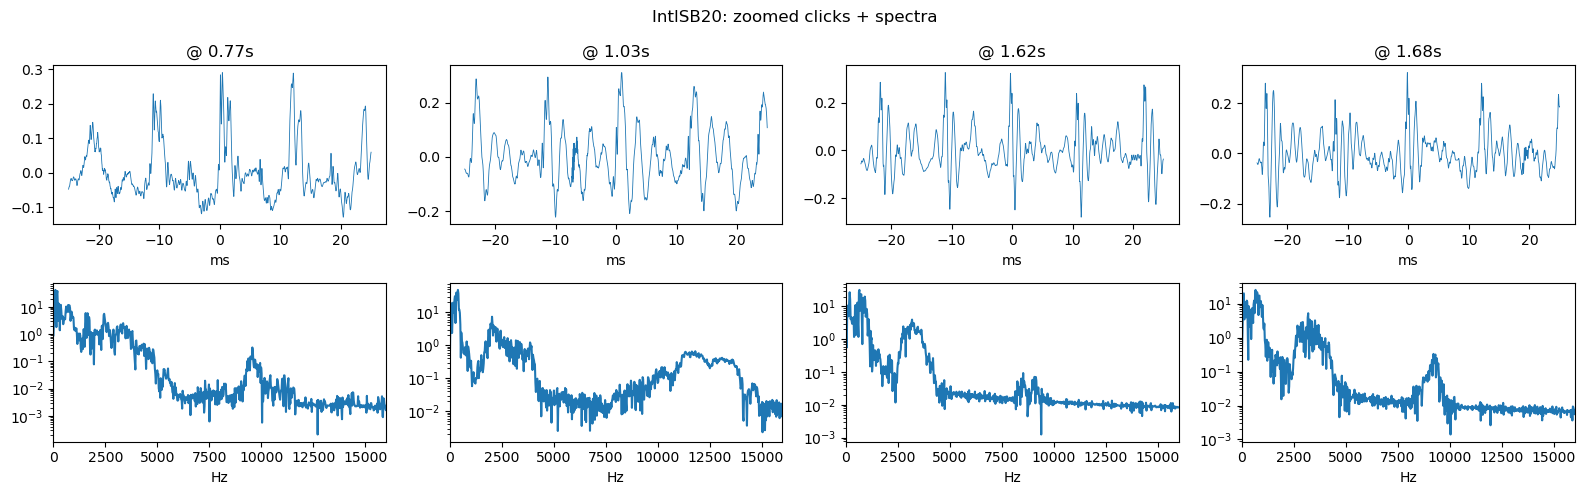

In [5]:
for w in wavs:
    y, sr = load(w)
    peaks, _, _ = detect_clicks(y, sr)
    sel = peaks[:4]
    fig, axes = plt.subplots(2, len(sel), figsize=(4 * len(sel), 5))
    half = int(sr * 0.025)
    for i, p in enumerate(sel):
        a, b = max(0, p - half), min(len(y), p + half)
        seg = y[a:b]; tt = (np.arange(a, b) - p) / sr * 1000
        axes[0, i].plot(tt, seg, lw=0.6); axes[0, i].set(title=f'@ {p/sr:.2f}s', xlabel='ms')
        S = np.abs(np.fft.rfft(seg * np.hanning(len(seg)), 2048)); f = np.fft.rfftfreq(2048, 1 / sr)
        axes[1, i].semilogy(f, S + 1e-9); axes[1, i].set(xlim=(0, 16000), xlabel='Hz')
    fig.suptitle(f'{w.stem}: zoomed clicks + spectra'); fig.tight_layout()
    fig.savefig(FIG_DIR / f'{w.stem}_clicks.png', dpi=90); plt.show()

## 结论 / Conclusions (4 个关键问题)

**基于本次运行的数据(上表 + `figures/`):**

**1. 点击瞬态形状与能量频段**
- 真正的单击是**极短的宽带瞬态**:主爆发约 **2–5 ms**(见 `BJ_C1` @1.92s / @2.09s 放大图),含微弱预/后振铃。
- 频谱呈**双段结构**:低频"砰"体(峰值常 < 500 Hz,来自台面/按键谐振)+ 延伸到 ~10–15 kHz 的宽带高频;判别性强的是**高频宽带**段。
- ⚠️ 表中 `d-20ms≈57 / d-40ms=60` 是"包络平滑 + ±30 ms 窗"造成的**饱和高估**,非真实时长;真实尖锐段以放大图为准(~2–5 ms)。

**2. 信噪比** — peak-SNR 全部 ≥ ~40 dB:`BJ_C3` 最佳(~61 dB)> `F67`(~51)> `BJ_C1`/`IntlSB20`(~40)。点击普遍显著高出噪声底,简单阈值即可起步;`IntlSB20` 噪声底最高(−39.9 dBFS),需谨慎。

**3. 干扰** — `IntlSB20` 整段频谱有持续低频带 + 检出 1084 个候选事件;`BJ_C1` 存在整段宽带噪声片段(如 @0.98s),疑似含敲击/说话/handling 等非点击瞬态。**建议用 audio-preview 试听确认**——这正是流水线 step 5(verify / 去重)要处理的对象。

**4. 文件差异(大)** — 噪声底跨度 21 dB(−39.9 ~ −61.0 dBFS),点击亮度 centroid 1271(IntlSB20)~ 4350 Hz(BJ_C1)。→ **必须用每文件自适应阈值**(median + delta),固定全局阈值不可行。

**对后续设计的直接结论:**
- **step 2 高通截止取 ~1.5–3 kHz** —— 压低低频体 / rumble,保留尖锐宽带瞬态。
- **step 3** 用 spectral flux + HFC 抓宽带 onset(高频段贡献最大)。
- **step 4** 自适应阈值 + 最小间距;本数据最密处点击间隔可低至 ~10 ms,`min_gap` 不宜设太大。

## ⚠️ 结论修正（2026-06-12，干扰人工确认后）

放大图中 ~10 ms 等距尖峰列**已人工试听确认为周期性环境干扰，不是鼠标点击**。
定量分析（脚本见会话记录，图见 `figures/interference_analysis.png`；
峰检测沿用本 notebook 的 0.12·max 阈值，但 min_dist 放宽到 4 ms 以保留尖峰列成员）：

| file | 干扰尖峰数 | 周期 (中位/自相关, ms) | 受影响时长 | 占比 |
| --- | --- | --- | --- | --- |
| BJ_C1 | 113 | 7.2 / 7.9 | 1.0 s | 0.3% |
| BJ_C3 | 466 | 6.5 / 5.4 | 4.1 s | 1.5% |
| F67 | 887 | 10.6 / 9.8 | 10.1 s | 2.9% |
| IntlSB20 | 3185 | 8.0 / 7.7 | 29.4 s | **8.0%** |

**对上方结论的修正：**

1. **"最密点击间隔可低至 ~10 ms、min_gap 不宜设大"一条作废** —— 10 ms 间隔全部来自干扰。
   真实点击最小间隔由 down-up（~60–150 ms）决定，`min_gap` 取 30–50 ms 是安全的。
2. **IntlSB20 的统计行（1084 候选、fpk 281 Hz、centroid 1271 Hz）被干扰严重污染**，
   剔除干扰后需重算；该文件适合留作困难测试集。
3. 干扰是宽带的（高通 2 kHz 后依然显著，IntlSB20 中 2–4 kHz 与点击同量级），
   **高通 + spectral flux/HFC 滤不掉** → `verify` 模块必须做**周期性剔除**
   （候选局部自相关 / 等距尖峰列整段否决）。F67/IntlSB20 中干扰在 >5 kHz 处比真点击弱,
   HFC 加权有一定区分度，但不充分。
4. 标注 ground truth 前先按周期性剔除干扰段，避免标注被污染。
